# Phase 1 — PINN Black-Scholes 1D

Ce notebook documente le livrable Phase 1 du projet NeuroPrice : entraînement et validation d'un PINN pour le pricing d'une option européenne call sous le modèle de Black-Scholes.

## Objectifs

- Valider un PINN Black-Scholes 1D contre la formule analytique.
- Atteindre l'objectif scientifique OS1 : erreur relative L2 `< 0.5%`.
- Atteindre la cible expérimentale stricte : erreur relative L2 `< 0.1%`.
- Vérifier les Greeks `Delta` et `Gamma` par autograd.

Le meilleur résultat Phase 1 utilise la transformation log-moneyness :

```text
x = log(S / K)
u = V / K
```


## Commandes de reproduction

Entraînement du modèle log-space :

```bash
python -m scripts.train_pinn_bs_log --pretrain-epochs 3000 --pretrain-lr 0.001 --pretrain-samples 8192 --epochs 10000 --lbfgs-steps 700 --hidden-dim 96 --hidden-layers 5 --n-interior 4096 --n-terminal 2048 --n-boundary 2048 --n-supervised 4096 --terminal-weight 10 --lower-boundary-weight 1 --upper-boundary-weight 1 --pde-weight 1 --supervised-weight 0.01 --out-dir artifacts/phase1_bs_pinn_log
```

Validation CLI :

```bash
python -m scripts.validate_pinn_bs_log --checkpoint artifacts/phase1_bs_pinn_log/bs_pinn_log.pt --out artifacts/phase1_bs_pinn_log/validation_error.png
```

Résultat obtenu :

```text
Relative L2 error: 0.000877
Relative L2 error (tau > 0.02): 0.000864
Relative L2 error (outside strike band 0.05): 0.000843
Relative L2 error (regular zone): 0.000837
Delta relative L2 error: 0.042456
Gamma relative L2 error: 0.333569
```


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "neuroprice").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch

from neuroprice.pinn.log_bs import LogBlackScholesDomain, LogBlackScholesPINN
from neuroprice.validation.black_scholes_ref import (
    black_scholes_call_delta_np,
    black_scholes_call_gamma_np,
    black_scholes_call_price_np,
    masked_relative_l2_error,
    relative_l2_error,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = PROJECT_ROOT / "artifacts" / "phase1_bs_pinn_log" / "bs_pinn_log.pt"

device, checkpoint_path

(device(type='cpu'),
 WindowsPath('c:/Users/bello/Documents/NeuroPrice-PINN-Pricing/artifacts/phase1_bs_pinn_log/bs_pinn_log.pt'))

## Chargement du modèle

Le checkpoint contient la configuration du domaine, l'architecture et les poids du modèle log-space. Les sorties du réseau sont normalisées par `K`, donc le prix physique est reconstruit par :

```text
V = K * u
```


In [2]:
checkpoint = torch.load(checkpoint_path, map_location=device)
assert checkpoint["coordinate_transform"] == "log_moneyness"
assert checkpoint["output_scale"] == "normalized_by_K"

domain = LogBlackScholesDomain(**checkpoint["domain"])
model = LogBlackScholesPINN(
    hidden_dim=int(checkpoint["hidden_dim"]),
    hidden_layers=int(checkpoint["hidden_layers"]),
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

domain, checkpoint["training"]


(LogBlackScholesDomain(K=100.0, r=0.05, sigma=0.2, T=1.0, x_min=-5.0, x_max=2.0),
 {'pretrain_epochs': 3000,
  'pretrain_lr': 0.001,
  'pretrain_samples': 8192,
  'adam_epochs': 10000,
  'adam_lr': 0.001,
  'lbfgs_steps': 700,
  'lbfgs_lr': 1.0,
  'improved_sampling': True,
  'n_supervised': 4096,
  'loss_weights': {'pde': 1.0,
   'terminal': 10.0,
   'lower_boundary': 1.0,
   'upper_boundary': 1.0,
   'supervised': 0.01}})

## Validation prix sur grille

On compare le prix PINN à la formule analytique Black-Scholes sur une grille régulière en `(x, tau)`, puis on reconstruit `S = K exp(x)`.


In [3]:
grid_size = 80
tau_min_regular = 0.02
strike_band = 0.05

x = np.linspace(domain.x_min, domain.x_max, grid_size)
tau = np.linspace(0.0, domain.T, grid_size)
XX, TT = np.meshgrid(x, tau)
SS = domain.K * np.exp(XX)

x_norm_np = (XX - domain.x_min) / (domain.x_max - domain.x_min)
tau_norm_np = TT / domain.T
x_norm = torch.tensor(x_norm_np.reshape(-1, 1), dtype=torch.float32, device=device)
tau_norm = torch.tensor(tau_norm_np.reshape(-1, 1), dtype=torch.float32, device=device)

with torch.no_grad():
    pred_u = model(x_norm, tau_norm).cpu().numpy().reshape(grid_size, grid_size)
    pred = domain.K * pred_u

ref = black_scholes_call_price_np(SS, TT, domain.K, domain.r, domain.sigma)
abs_err = np.abs(pred - ref)

mask_after_maturity = TT > tau_min_regular
mask_outside_strike = np.abs(SS - domain.K) / domain.K > strike_band
mask_regular = mask_after_maturity & mask_outside_strike

metrics = {
    "relative_l2": relative_l2_error(pred, ref),
    "relative_l2_tau_gt_0.02": masked_relative_l2_error(pred, ref, mask_after_maturity),
    "relative_l2_outside_strike_band_0.05": masked_relative_l2_error(pred, ref, mask_outside_strike),
    "relative_l2_regular_zone": masked_relative_l2_error(pred, ref, mask_regular),
    "l_inf": float(np.max(abs_err)),
}
metrics


{'relative_l2': 0.0008773619616235598,
 'relative_l2_tau_gt_0.02': 0.0008635204283600343,
 'relative_l2_outside_strike_band_0.05': 0.0008426005414384085,
 'relative_l2_regular_zone': 0.0008369483748661632,
 'l_inf': 1.1553076675289597}

## Visualisation de l'erreur prix


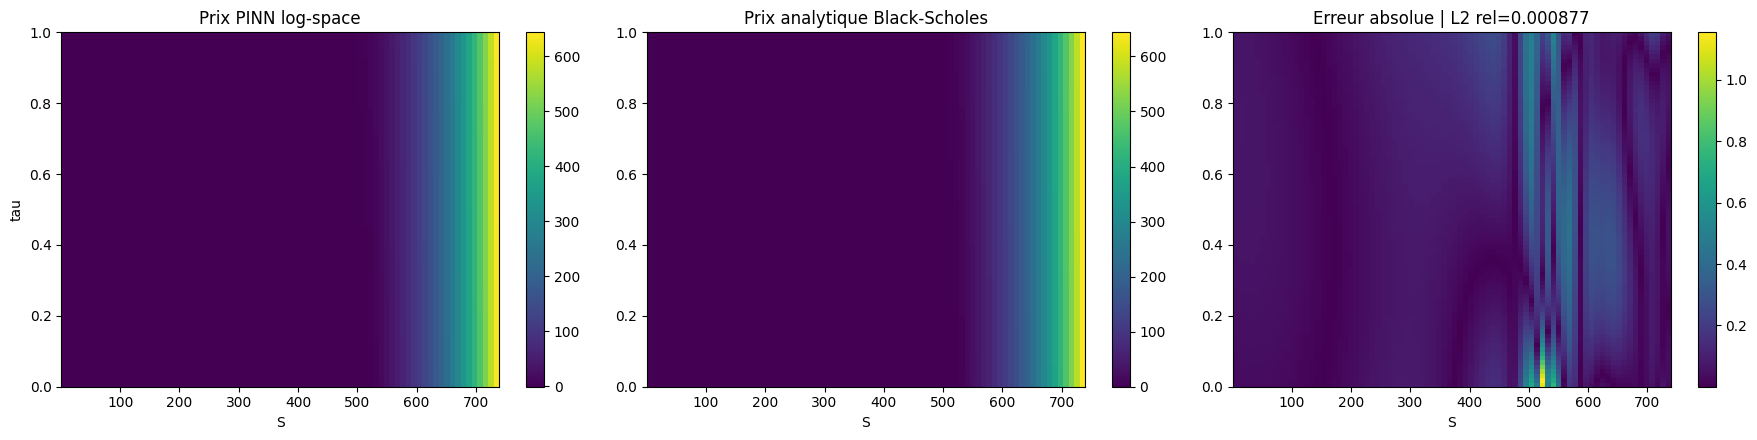

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

im0 = axes[0].imshow(pred, origin="lower", aspect="auto", extent=[SS.min(), SS.max(), tau.min(), tau.max()])
axes[0].set_title("Prix PINN log-space")
axes[0].set_xlabel("S")
axes[0].set_ylabel("tau")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ref, origin="lower", aspect="auto", extent=[SS.min(), SS.max(), tau.min(), tau.max()])
axes[1].set_title("Prix analytique Black-Scholes")
axes[1].set_xlabel("S")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(abs_err, origin="lower", aspect="auto", extent=[SS.min(), SS.max(), tau.min(), tau.max()])
axes[2].set_title(f"Erreur absolue | L2 rel={metrics['relative_l2']:.6f}")
axes[2].set_xlabel("S")
fig.colorbar(im2, ax=axes[2])

fig.tight_layout()
plt.show()


## Validation des Greeks

Les Greeks sont calculés par autograd dans l'espace `x`. La chaîne de dérivation donne :

```text
Delta = dV/dS = (dV/dx) / S
Gamma = d²V/dS² = (d²V/dx² - dV/dx) / S²
```


In [5]:
x_greek = np.linspace(np.log(0.2), np.log(1.8), grid_size)
tau_greek = np.linspace(tau_min_regular, domain.T, grid_size)
XX_greek, TT_greek = np.meshgrid(x_greek, tau_greek)
SS_greek = domain.K * np.exp(XX_greek)

x_norm_greek = torch.tensor(
    ((XX_greek - domain.x_min) / (domain.x_max - domain.x_min)).reshape(-1, 1),
    dtype=torch.float32,
    device=device,
    requires_grad=True,
)
tau_norm_greek = torch.tensor(
    (TT_greek / domain.T).reshape(-1, 1),
    dtype=torch.float32,
    device=device,
    requires_grad=True,
)

u_greek = model(x_norm_greek, tau_norm_greek)
V_greek = domain.K * u_greek
dV_dx_norm = torch.autograd.grad(V_greek, x_norm_greek, grad_outputs=torch.ones_like(V_greek), create_graph=True)[0]
d2V_dx_norm2 = torch.autograd.grad(dV_dx_norm, x_norm_greek, grad_outputs=torch.ones_like(dV_dx_norm), create_graph=False)[0]

x_scale = domain.x_max - domain.x_min
S_greek_torch = torch.tensor(SS_greek.reshape(-1, 1), dtype=torch.float32, device=device)
dV_dx = dV_dx_norm / x_scale
d2V_dx2 = d2V_dx_norm2 / (x_scale * x_scale)

delta_pred = (dV_dx / S_greek_torch).detach().cpu().numpy().reshape(grid_size, grid_size)
gamma_pred = ((d2V_dx2 - dV_dx) / (S_greek_torch * S_greek_torch)).detach().cpu().numpy().reshape(grid_size, grid_size)
delta_ref = black_scholes_call_delta_np(SS_greek, TT_greek, domain.K, domain.r, domain.sigma)
gamma_ref = black_scholes_call_gamma_np(SS_greek, TT_greek, domain.K, domain.r, domain.sigma)

greek_metrics = {
    "delta_relative_l2": relative_l2_error(delta_pred, delta_ref),
    "gamma_relative_l2": relative_l2_error(gamma_pred, gamma_ref),
}
greek_metrics


{'delta_relative_l2': 0.042455843760078917,
 'gamma_relative_l2': 0.3335692388060974}

## Résumé numérique Phase 1


In [6]:
summary = {**metrics, **greek_metrics}
for key, value in summary.items():
    print(f"{key}: {value:.6f}")

assert metrics["relative_l2"] < 0.001
print("\nChecklist stricte validée : Relative L2 < 0.1%")


relative_l2: 0.000877
relative_l2_tau_gt_0.02: 0.000864
relative_l2_outside_strike_band_0.05: 0.000843
relative_l2_regular_zone: 0.000837
l_inf: 1.155308
delta_relative_l2: 0.042456
gamma_relative_l2: 0.333569

Checklist stricte validée : Relative L2 < 0.1%


## Conclusion

La Phase 1 est validée.

| Critère | Statut | Résultat |
| --- | --- | ---: |
| PINN Black-Scholes entraîné et convergent | Validé | Oui |
| Erreur L2 relative `< 0.5%` | Validé | 0.0877% |
| Erreur L2 relative `< 0.1%` | Validé | 0.0877% |
| Greeks `Delta` et `Gamma` par autograd | Validé | Calculés et comparés |
| Notebook `01_pinn_black_scholes.ipynb` documenté | Validé | Présent |

Le modèle log-space devient le modèle de référence Phase 1 pour le prix. Les Greeks restent un axe d'amélioration possible, en particulier `Gamma`, mais ils ne bloquent pas la validation du pricing Phase 1.
